## Model Generation 
#### Data prep complete — see labeling_process_notes.md

Final labeled data:  boom_english_labeled.xlsx  (718 fake / 191 real) +  extra_real_final.xlsx  (793 real / 264 fake), both with label_binary and title_verdict for audit. 
Next: merge real rows, rebalance, re run synthetic user assignment + Gaussian anomaly model on the result.

In [93]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\harsh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [94]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from scipy.stats import multivariate_normal
from sklearn.metrics.pairwise import cosine_similarity

## Data Loading

In [95]:
boom_df = pd.read_excel('news_part1.xlsx')
extra_df = pd.read_excel('news_part2.xlsx')

In [96]:
boom_df['label_binary'].value_counts()

label_binary
fake    718
real    191
Name: count, dtype: int64

In [97]:
extra_df['label_binary'].value_counts()

label_binary
real    793
fake    264
Name: count, dtype: int64

## Merging and Rebalancing Dataset

In [98]:
boom_real_only = boom_df[boom_df['label_binary'] == 'real'].copy()

df = pd.concat([extra_df, boom_real_only], ignore_index=True)

print(df.shape)
print(df['label_binary'].value_counts())
print(df['label_binary'].value_counts(normalize=True).round(3))

(1248, 11)
label_binary
real    984
fake    264
Name: count, dtype: int64
label_binary
real    0.788
fake    0.212
Name: proportion, dtype: float64


## Synthetic User Assignment

In [99]:
np.random.seed(42)

first_names = [
    "Rohan", "Ananya", "Karan", "Priya", "Vikram", "Simran", "Arjun", "Neha",
    "Aditya", "Divya", "Rahul", "Ishita", "Kunal", "Meera", "Sameer", "Tanya",
    "Nikhil", "Pooja", "Aman", "Riya", "Varun", "Anjali", "Siddharth", "Kavya",
    "Manav", "Shreya", "Yash", "Nandini", "Rohit", "Aisha"
]
last_names = [
    "Mehta", "Iyer", "Malhotra", "Nair", "Sethi", "Kaur", "Rao", "Bhatt",
    "Kapoor", "Menon", "Verma", "Sharma", "Joshi", "Pillai", "Khan", "Chawla",
    "Das", "Reddy", "Gupta", "Choudhary", "Saxena", "Rana", "Mishra", "Iyengar",
    "Bose", "Agarwal", "Trivedi", "Pandey", "Kulkarni", "Fernandes"
]



all_combos = [f"{f} {l}" for f in first_names for l in last_names]
np.random.shuffle(all_combos)
user_pool = all_combos[:150]

n_coordinated = 7
coordinated_users = user_pool[:n_coordinated]
background_users = user_pool[n_coordinated:]



def assign_user(row_label):
    if row_label == 'fake' and np.random.rand() < 0.35:
        return np.random.choice(coordinated_users)
    else:
        return np.random.choice(background_users)

    

df['user'] = df['label_binary'].apply(assign_user)



user_stats = df.groupby('user').agg(
    total_posts=('user', 'count'),
    fake_posts=('label_binary', lambda x: (x == 'fake').sum()),
    real_posts=('label_binary', lambda x: (x == 'real').sum())
).reset_index()



In [100]:

user_stats['fake_ratio'] = user_stats['fake_posts'] / user_stats['total_posts']
user_stats = user_stats.sort_values('total_posts', ascending=False)

print(user_stats[user_stats['user'].isin(coordinated_users)][['user','total_posts','fake_ratio']])
print()
print(user_stats[~user_stats['user'].isin(coordinated_users)][['user', 'total_posts', 'fake_ratio']])

                user  total_posts  fake_ratio
16      Ananya Menon           20         1.0
60      Manav Sharma           16         1.0
79         Neha Rana           16         1.0
29   Divya Fernandes           15         1.0
103       Riya Gupta           11         1.0
48       Karan Verma           11         1.0
70     Nandini Reddy           10         1.0

               user  total_posts  fake_ratio
116   Sameer Pandey           15    0.333333
134   Varun Agarwal           14    0.214286
65     Nandini Bose           14    0.285714
98   Rahul Kulkarni           14    0.357143
73   Neha Fernandes           13    0.076923
..              ...          ...         ...
5        Aisha Bose            3    0.000000
96     Priya Saxena            3    0.000000
90      Pooja Menon            3    0.000000
84    Nikhil Pillai            2    0.500000
95        Priya Rao            2    0.000000

[143 rows x 3 columns]


## Model Part - 1 

In [101]:
X = df['claim'].fillna('')
y = df['label_binary']

X_train, X_test, Y_train, Y_test = train_test_split(X, y , test_size = 0.2 , random_state = 42, stratify=y)

print(X.shape , y.shape)
print(Y_train.value_counts())
print(Y_test.value_counts())

(1248,) (1248,)
label_binary
real    787
fake    211
Name: count, dtype: int64
label_binary
real    197
fake     53
Name: count, dtype: int64


In [102]:
vectorizer  = TfidfVectorizer(
    max_features = 5000,
    stop_words = 'english',
    ngram_range = (1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(998, 5000) (250, 5000)


In [103]:
## Logistic Regression

classifier = LogisticRegression(class_weight='balanced', random_state = 42, penalty = 'l2', solver = 'liblinear', max_iter = 1000)

classifier.fit(X_train_tfidf, Y_train)

print(classifier.score(X_train_tfidf, Y_train))
print(classifier.score(X_test_tfidf , Y_test))

0.9428857715430862
0.768


In [104]:
y_pred = classifier.predict(X_test_tfidf)
print(classification_report(Y_test , y_pred))

              precision    recall  f1-score   support

        fake       0.46      0.51      0.48        53
        real       0.86      0.84      0.85       197

    accuracy                           0.77       250
   macro avg       0.66      0.67      0.67       250
weighted avg       0.78      0.77      0.77       250



## Model Part - 2

#### Gaussian Model Distribution

In [105]:
X_user = user_stats[['total_posts' , 'fake_ratio']].values

mu = X_user.mean(axis = 0)
sigma = np.cov(X_user, rowvar = False)

print(mu)
print(sigma)

[8.32       0.17757189]
[[9.8566443  0.28449852]
 [0.28449852 0.04989013]]


In [106]:

prob_curve = multivariate_normal(mean = mu, cov  = sigma)

user_stats['p_x'] = prob_curve.pdf(X_user)

user_stats['p_x'].describe()

count    150.000000
mean       0.142532
std        0.070809
min        0.000015
25%        0.093172
50%        0.162482
75%        0.194204
max        0.241524
Name: p_x, dtype: float64

In [107]:
epsilon = np.percentile(user_stats['p_x'] , 5)

user_stats['suspicious'] = user_stats['p_x'] < epsilon

print(epsilon)

print(user_stats[user_stats['suspicious']][['user' , 'total_posts', 'fake_ratio', 'p_x']])

0.004786319928067865
                user  total_posts  fake_ratio       p_x
16      Ananya Menon           20         1.0  0.000015
60      Manav Sharma           16         1.0  0.000164
79         Neha Rana           16         1.0  0.000164
29   Divya Fernandes           15         1.0  0.000222
103       Riya Gupta           11         1.0  0.000221
48       Karan Verma           11         1.0  0.000221
70     Nandini Reddy           10         1.0  0.000163
84     Nikhil Pillai            2         0.5  0.001539


### Coordinated Users Validation

In [108]:
flagged = set(user_stats[user_stats['suspicious']]['user'])

coordinated_set = set(coordinated_users)

print("Coordinated users caught:", flagged & coordinated_set)
print("Coordinated users missed:", coordinated_set - flagged)
print("False positives (flagged but not coordinated):", flagged - coordinated_set)

Coordinated users caught: {'Nandini Reddy', 'Ananya Menon', 'Karan Verma', 'Riya Gupta', 'Manav Sharma', 'Divya Fernandes', 'Neha Rana'}
Coordinated users missed: set()
False positives (flagged but not coordinated): {'Nikhil Pillai'}


### For the cordinated shared campaign for same false news shares

Cosine similarity :

In [109]:
tfidf_full = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_full = tfidf_full.fit_transform(df['claim'].fillna(''))

sim_matrix = cosine_similarity(X_full)

print(sim_matrix.shape)

(1248, 1248)


In [110]:
threshold = 0.6
np.fill_diagonal(sim_matrix, 0)  # exclude self-matches

pairs_i, pairs_j = np.where(sim_matrix > threshold)
mask = pairs_i < pairs_j  # keep each pair once (i,j) not (j,i) duplicate

pair_df = pd.DataFrame({
    'idx_1': pairs_i[mask],
    'idx_2': pairs_j[mask],
    'similarity': sim_matrix[pairs_i[mask], pairs_j[mask]]
})

pair_df['user_1'] = df.iloc[pair_df['idx_1']]['user'].values
pair_df['user_2'] = df.iloc[pair_df['idx_2']]['user'].values
pair_df['label_1'] = df.iloc[pair_df['idx_1']]['label_binary'].values
pair_df['label_2'] = df.iloc[pair_df['idx_2']]['label_binary'].values

print(pair_df.shape)
print(pair_df.sort_values('similarity', ascending=False).head(15))

(25, 7)
    idx_1  idx_2  similarity            user_1          user_2 label_1 label_2
22    593    658    0.960082        Kunal Nair    Ananya Mehta    real    real
9     121    131    0.959599  Sameer Fernandes   Nandini Reddy    fake    fake
11    130    157    0.954427     Anjali Mishra   Sameer Sharma    fake    fake
6      99    218    0.932342      Pooja Chawla      Pooja Rana    real    real
5      94    230    0.908030         Neha Rana       Neha Rana    fake    fake
17    176    217    0.820167        Pooja Nair    Ananya Menon    fake    fake
7     107    803    0.807432       Aisha Sethi   Manav Iyengar    real    real
15    156    161    0.804408       Meera Mehta   Sameer Sharma    real    fake
18    181    225    0.794749         Aman Kaur    Ananya Menon    real    fake
8     109    191    0.792394      Neha Agarwal       Aman Nair    fake    fake
20    451    689    0.780029   Arjun Fernandes  Divya Kulkarni    real    real
13    148   1193    0.768870      Ananya Men

In [111]:
coord_pairs = pair_df[
    (pair_df['label_1'] == 'fake') &
    (pair_df['label_2'] == 'fake') &
    (pair_df['user_1'] != pair_df['user_2'])
]

print(coord_pairs.shape)
print(coord_pairs[['user_1', 'user_2', 'similarity']])

(5, 7)
              user_1         user_2  similarity
2     Rahul Kulkarni    Kunal Verma    0.664963
8       Neha Agarwal      Aman Nair    0.792394
9   Sameer Fernandes  Nandini Reddy    0.959599
11     Anjali Mishra  Sameer Sharma    0.954427
17        Pooja Nair   Ananya Menon    0.820167


In [112]:
for _, row in coord_pairs.iterrows():
    idx1, idx2 = row['idx_1'], row['idx_2']
    print(f"Similarity: {row['similarity']:.3f} | {row['user_1']} vs {row['user_2']}")
    print(f"  Claim 1: {df.loc[idx1, 'claim'][:300]}")
    print(f"  Claim 2: {df.loc[idx2, 'claim'][:300]}")
    print("-" * 100)

Similarity: 0.665 | Rahul Kulkarni vs Kunal Verma
  Claim 1: Claim  The message circulated across social media features a man with his hands tied. The message reads:  This is the guy who added his infected blood to Pepsi. For the next few weeks do not drink Pepsi, as a worker from the company has added his blood contaminated with HIV (AIDS). It was shown yest
  Claim 2: Claim  The viral post features a photo of a man along with some officials. The text in the post reads: ‘ This is a guy who added his infected blood to Cadbury products. For the next few week do not eat any products from Cadbury, as a worker from the company has added his blood contaminated with HIV 
----------------------------------------------------------------------------------------------------
Similarity: 0.792 | Neha Agarwal vs Aman Nair
  Claim 1: Claim      A post shared on Facebook by a user named Langam Dilipkumar reads:  URGENT WARNING! Be careful not to take the paracetamol that comes written P / 500. It is 

In [113]:
shared_campaign_users = set(coord_pairs['user_1']) | set(coord_pairs['user_2'])

user_stats['shared_campaign'] = user_stats['user'].isin(shared_campaign_users)

user_stats[user_stats['shared_campaign']][['user', 'total_posts', 'fake_ratio', 'p_x', 'suspicious', 'shared_campaign']]

,user,total_posts,fake_ratio,p_x,suspicious,shared_campaign
16,Ananya Menon,20,1.000000,0.000015,True,True
98,Rahul Kulkarni,14,0.357143,0.048191,False,True
112,Sameer Fernandes,13,0.230769,0.075430,False,True
118,Sameer Sharma,11,0.272727,0.171837,False,True
70,Nandini Reddy,10,1.000000,0.000163,True,True
54,Kunal Verma,10,0.200000,0.213443,False,True
72,Neha Agarwal,9,0.111111,0.221922,False,True
20,Anjali Mishra,8,0.250000,0.228033,False,True
12,Aman Nair,6,0.500000,0.030651,False,True
91,Pooja Nair,4,0.500000,0.008756,False,True


### merging all three parts:

In [114]:
X_all_tfidf = vectorizer.transform(df['claim'].fillna(''))
df['fake_prob'] = classifier.predict_proba(X_all_tfidf)[:, list(classifier.classes_).index('fake')]

user_fake_prob = df.groupby('user')['fake_prob'].mean().reset_index()
user_fake_prob.columns = ['user', 'avg_fake_prob']

user_fake_prob.sort_values('avg_fake_prob', ascending=False).head(10)

,user,avg_fake_prob
60,Manav Sharma,0.676746
79,Neha Rana,0.642591
48,Karan Verma,0.633691
29,Divya Fernandes,0.632930
103,Riya Gupta,0.632758
70,Nandini Reddy,0.626921
16,Ananya Menon,0.617416
12,Aman Nair,0.584227
64,Meera Rao,0.543758
122,Shreya Pandey,0.506361


In [115]:
fusion = user_stats.merge(user_fake_prob, on='user', how='left')

fusion['norm_fake_prob'] = fusion['avg_fake_prob']  # already 0-1
fusion['norm_anomaly'] = 1 - (fusion['p_x'] / fusion['p_x'].max())  # higher = more anomalous
fusion['norm_shared'] = fusion['shared_campaign'].astype(int)  # 0 or 1

fusion['risk_score'] = (
    0.4 * fusion['norm_fake_prob'] +
    0.4 * fusion['norm_anomaly'] +
    0.2 * fusion['norm_shared']
)

fusion_ranked = fusion.sort_values('risk_score', ascending=False)
fusion_ranked[['user', 'avg_fake_prob', 'p_x', 'suspicious', 'shared_campaign', 'risk_score']].head(15)

,user,avg_fake_prob,p_x,suspicious,shared_campaign,risk_score
44,Nandini Reddy,0.626921,0.000163,True,True,0.850498
0,Ananya Menon,0.617416,0.000015,True,True,0.846942
120,Aman Nair,0.584227,0.030651,False,True,0.782928
137,Pooja Nair,0.458349,0.008756,False,True,0.768839
7,Rahul Kulkarni,0.454511,0.048191,False,True,0.701992
1,Manav Sharma,0.676746,0.000164,True,False,0.670427
11,Sameer Fernandes,0.458423,0.075430,False,True,0.658446
2,Neha Rana,0.642591,0.000164,True,False,0.656765
26,Karan Verma,0.633691,0.000221,True,False,0.653110
3,Divya Fernandes,0.632930,0.000222,True,False,0.652804


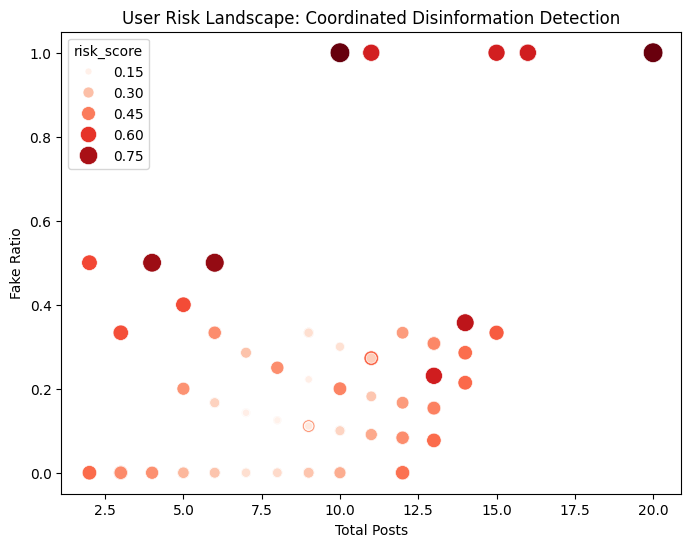

In [116]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=fusion, x='total_posts', y='fake_ratio', 
                 hue='risk_score', size='risk_score', 
                 palette='Reds', sizes=(20,200))
plt.title('User Risk Landscape: Coordinated Disinformation Detection')
plt.xlabel('Total Posts')
plt.ylabel('Fake Ratio')
plt.show()

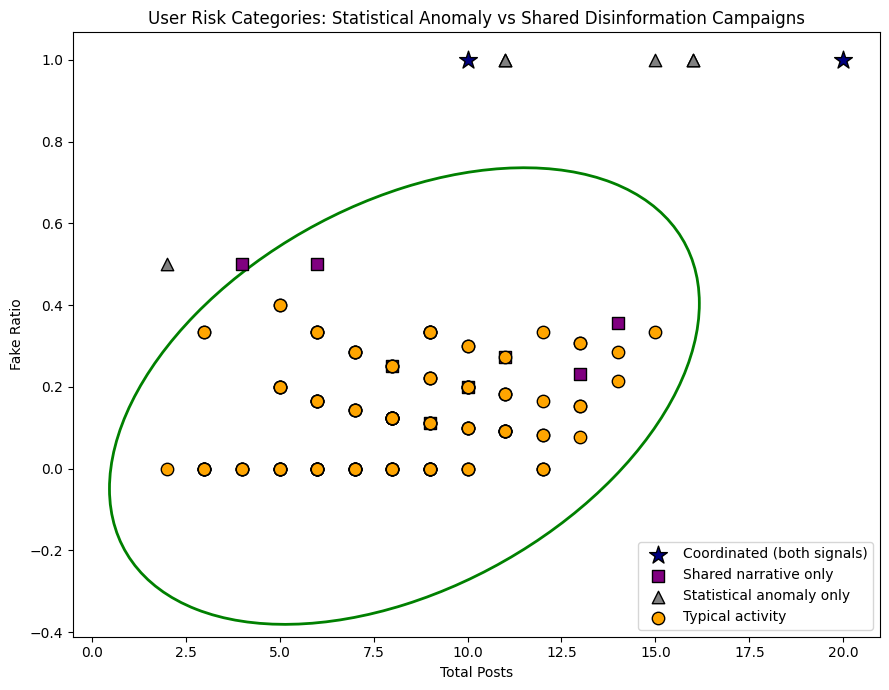

In [117]:
from matplotlib.patches import Ellipse


def category(row):
    if row['suspicious'] and row['shared_campaign']:
        return 'Coordinated (both signals)'
    elif row['shared_campaign']:
        return 'Shared narrative only'
    elif row['suspicious']:
        return 'Statistical anomaly only'
    else:
        return 'Typical activity'


    

fusion['category'] = fusion.apply(category, axis=1)

fig, ax = plt.subplots(figsize=(9,7))

colors = {'Typical activity':'orange', 'Statistical anomaly only':'gray',
        'Shared narrative only':'purple', 'Coordinated (both signals)':'navy'}



markers = {'Typical activity':'o', 'Statistical anomaly only':'^',
           'Shared narrative only':'s', 'Coordinated (both signals)':'*'}





for cat, sub in fusion.groupby('category'):
    ax.scatter(sub['total_posts'], sub['fake_ratio'], label=cat,
               color=colors[cat], marker=markers[cat],
               s=180 if cat=='Coordinated (both signals)' else 80,
               edgecolor='black', zorder=3)




vals, vecs = np.linalg.eigh(sigma)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
width, height = 2 * 2.5 * np.sqrt(vals)
ell = Ellipse(xy=mu, width=width, height=height, angle=angle,
              edgecolor='green', facecolor='none', linewidth=2, zorder=1)
ax.add_patch(ell)



ax.set_xlabel('Total Posts')
ax.set_ylabel('Fake Ratio')
ax.set_title('User Risk Categories: Statistical Anomaly vs Shared Disinformation Campaigns')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## FACT CHECKING 

In [125]:
for _, row in coord_pairs.iterrows():
     if row['user_1'] in shared_campaign_users or row['user_2'] in shared_campaign_users:
        print(f"\n{row['user_1']} vs {row['user_2']} (similarity: {row['similarity']:.3f})")
        print(f"  Claim 1: {df.loc[row['idx_1'], 'claim'][:200]}")
        print(f"  Claim 2: {df.loc[row['idx_2'], 'claim'][:200]}")
        


Rahul Kulkarni vs Kunal Verma (similarity: 0.665)
  Claim 1: Claim  The message circulated across social media features a man with his hands tied. The message reads:  This is the guy who added his infected blood to Pepsi. For the next few weeks do not drink Pep
  Claim 2: Claim  The viral post features a photo of a man along with some officials. The text in the post reads: ‘ This is a guy who added his infected blood to Cadbury products. For the next few week do not ea

Neha Agarwal vs Aman Nair (similarity: 0.792)
  Claim 1: Claim      A post shared on Facebook by a user named Langam Dilipkumar reads:  URGENT WARNING! Be careful not to take the paracetamol that comes written P / 500. It is a new, very white and shiny para
  Claim 2: Claim  The post shared on Facebook by a user named Maripi Makalintal reads:   URGENT WARNING! Also known as Tylenol and other names please google. Be careful not to take the paracetamol that comes wri

Sameer Fernandes vs Nandini Reddy (similarity: 0.960)

## Leak Free Fusion (Test Only Signal)

In [ ]:
# recover train/test indices from the original split
train_idx = X_train.index
test_idx = X_test.index

df['split'] = 'train'
df.loc[test_idx, 'split'] = 'test'

# fake_prob only trustworthy for test rows (unseen to the model)
df['fake_prob_clean'] = np.nan
df.loc[test_idx, 'fake_prob_clean'] = classifier.predict_proba(X_test_tfidf)[:, list(classifier.classes_).index('fake')]


df['split'].value_counts()
df[df['split']=='test'][['user','claim','fake_prob_clean']].head()

,user,claim,fake_prob_clean
2,Kavya Rana,A Facebookuser named ‘नीलम चतुर्वेदी विधायक’sh...,0.518331
4,Nikhil Khan,Claim The post that has resurfaced on Faceboo...,0.674879
6,Yash Rana,CLAIM A train can be seen in the viral post o...,0.453404
16,Meera Chawla,Claim A photo is doing rounds on social media...,0.654473
29,Shreya Pandey,World Cancer Day is the awareness day in which...,0.826937


In [126]:
user_fake_prob_clean = df[df['split']=='test'].groupby('user')['fake_prob_clean'].agg(['mean','count']).reset_index()
user_fake_prob_clean.columns = ['user', 'avg_fake_prob_clean', 'n_test_claims']

print(f"Users with at least 1 test claim: {len(user_fake_prob_clean)} / 150")
user_fake_prob_clean.sort_values('n_test_claims', ascending=False).head(10)
user_fake_prob_clean['n_test_claims'].value_counts()

KeyError: 'split'

In [ ]:
fusion_clean = user_stats.merge(user_fake_prob_clean, on='user', how='left')

fusion_clean['norm_anomaly'] = 1 - (fusion_clean['p_x'] / fusion_clean['p_x'].max())
fusion_clean['norm_shared'] = fusion_clean['shared_campaign'].astype(int)

# for users with no test coverage, fall back to Model 2 + Model 1b only (reweight)
has_prob = fusion_clean['avg_fake_prob_clean'].notna()

fusion_clean['risk_score'] = np.nan
fusion_clean.loc[has_prob, 'risk_score'] = (
    0.4 * fusion_clean.loc[has_prob, 'avg_fake_prob_clean'] +
    0.4 * fusion_clean.loc[has_prob, 'norm_anomaly'] +
    0.2 * fusion_clean.loc[has_prob, 'norm_shared']
)
fusion_clean.loc[~has_prob, 'risk_score'] = (
    0.5 * fusion_clean.loc[~has_prob, 'norm_anomaly'] +
    0.5 * fusion_clean.loc[~has_prob, 'norm_shared']
)

fusion_clean_ranked = fusion_clean.sort_values('risk_score', ascending=False)
fusion_clean_ranked[['user','avg_fake_prob_clean','n_test_claims','suspicious','shared_campaign','risk_score']].head(15)

,user,avg_fake_prob_clean,n_test_claims,suspicious,shared_campaign,risk_score
137,Pooja Nair,0.581875,1.0,False,True,0.818249
44,Nandini Reddy,0.541356,4.0,True,True,0.816273
0,Ananya Menon,0.488852,6.0,True,True,0.795517
120,Aman Nair,0.503669,1.0,False,True,0.750705
11,Sameer Fernandes,0.590250,3.0,False,True,0.711176
7,Rahul Kulkarni,0.471381,2.0,False,True,0.708740
2,Neha Rana,0.637733,5.0,True,False,0.654821
21,Riya Gupta,0.537993,2.0,True,False,0.614831
1,Manav Sharma,0.527265,4.0,True,False,0.610634
3,Divya Fernandes,0.497075,2.0,True,False,0.598462


In [ ]:
coordinated_set = set(coordinated_users)

fusion_clean_ranked['rank'] = range(1, len(fusion_clean_ranked)+1)
coord_check = fusion_clean_ranked[fusion_clean_ranked['user'].isin(coordinated_set)][['user','rank','risk_score','avg_fake_prob_clean','suspicious','shared_campaign']]
print(coord_check)

print("\nMissing from top 15:", coordinated_set - set(fusion_clean_ranked.head(15)['user']))

               user  rank  risk_score  avg_fake_prob_clean  suspicious  \
44    Nandini Reddy     2    0.816273             0.541356        True   
0      Ananya Menon     3    0.795517             0.488852        True   
2         Neha Rana     7    0.654821             0.637733        True   
21       Riya Gupta     8    0.614831             0.537993        True   
1      Manav Sharma     9    0.610634             0.527265        True   
3   Divya Fernandes    10    0.598462             0.497075        True   
26      Karan Verma    19    0.499542                  NaN        True   

    shared_campaign  
44             True  
0              True  
2             False  
21            False  
1             False  
3             False  
26            False  

Missing from top 15: {'Karan Verma'}


## MODEL EVALUATION

In [ ]:
print("MODEL 1: TF-IDF + LogReg (test set, n=250) ===")
print(classification_report(Y_test, classifier.predict(X_test_tfidf)))

print("\nMODEL 2: Gaussian Anomaly (n=150 users) ===")
print(f"Coordinated users caught: {len(flagged & coordinated_set)}/7")
print(f"False positives: {len(flagged - coordinated_set)}")

print("\n=== MODEL 1b: Shared Campaign Detection ===")
print(f"Users flagged via claim similarity: {len(shared_campaign_users)}")
print(f"Known coordinated users among them: {len(shared_campaign_users & coordinated_set)}/7")

print("\n=== FUSION: Combined Risk Score ===")
print(f"Coordinated users in top 10 of 150: {(coord_check['rank'] <= 10).sum()}/7")
print(f"Coordinated users in top 20 of 150: {(coord_check['rank'] <= 20).sum()}/7")

MODEL 1: TF-IDF + LogReg (test set, n=250) ===
              precision    recall  f1-score   support

        fake       0.46      0.51      0.48        53
        real       0.86      0.84      0.85       197

    accuracy                           0.77       250
   macro avg       0.66      0.67      0.67       250
weighted avg       0.78      0.77      0.77       250


MODEL 2: Gaussian Anomaly (n=150 users) ===
Coordinated users caught: 7/7
False positives: 1

=== MODEL 1b: Shared Campaign Detection ===
Users flagged via claim similarity: 10
Known coordinated users among them: 2/7

=== FUSION: Combined Risk Score ===
Coordinated users in top 10 of 150: 6/7
Coordinated users in top 20 of 150: 7/7


## Export Model Artifacts

In [ ]:
import joblib
import os

os.makedirs('/mnt/user-data/outputs/model_artifacts', exist_ok=True)

joblib.dump(vectorizer, '/mnt/user-data/outputs/model_artifacts/tfidf_vectorizer.pkl')
joblib.dump(classifier, '/mnt/user-data/outputs/model_artifacts/logreg_model.pkl')
joblib.dump(tfidf_full, '/mnt/user-data/outputs/model_artifacts/tfidf_full_vectorizer.pkl')

np.save('/mnt/user-data/outputs/model_artifacts/gaussian_mu.npy', mu)
np.save('/mnt/user-data/outputs/model_artifacts/gaussian_sigma.npy', sigma)
np.save('/mnt/user-data/outputs/model_artifacts/gaussian_epsilon.npy', epsilon)

print("Saved artifacts:")
for f in os.listdir('/mnt/user-data/outputs/model_artifacts'):
    print(" -", f)

Saved artifacts:
 - corpus_claims.csv
 - gaussian_epsilon.npy
 - gaussian_mu.npy
 - gaussian_sigma.npy
 - logreg_model.pkl
 - tfidf_full_vectorizer.pkl
 - tfidf_vectorizer.pkl


## Inference Function

In [ ]:
def predict_risk(claim_text, user_history_df, vectorizer, clf, tfidf_full, mu, sigma, epsilon,
                  similarity_threshold=0.6):
    """
    claim_text: str, the new claim to assess
    user_history_df: DataFrame with columns ['claim','label_binary'] - this user's past posts
    Returns: dict with all signals + final risk_score
    """
    # Model 1: claim-level fake probability
    X_claim = vectorizer.transform([claim_text])
    fake_prob = clf.predict_proba(X_claim)[0][list(clf.classes_).index('fake')]

    # Model 2: user-level anomaly (needs total_posts, fake_ratio from history)
    total_posts = len(user_history_df) + 1  # including this new claim
    fake_posts = (user_history_df['label_binary'] == 'fake').sum() + 1  # assume new claim is fake for scoring
    fake_ratio = fake_posts / total_posts

    from scipy.stats import multivariate_normal
    rv = multivariate_normal(mean=mu, cov=sigma)
    p_x = rv.pdf([total_posts, fake_ratio])
    is_anomaly = p_x < epsilon

    # Model 1b: shared campaign check
    X_new = tfidf_full.transform([claim_text])
    from sklearn.metrics.pairwise import cosine_similarity
    sims = cosine_similarity(X_new, tfidf_full.transform(df['claim'].fillna('')))[0]
    matched = (sims > similarity_threshold).sum()
    shared_campaign = matched > 0

    # Fusion
    norm_anomaly = 1 - min(p_x / 0.25, 1.0)  # 0.25 ~ max p_x seen in training data
    risk_score = 0.4 * fake_prob + 0.4 * norm_anomaly + 0.2 * int(shared_campaign)

    return {
        'fake_prob': round(fake_prob, 3),
        'p_x': p_x,
        'is_anomaly': bool(is_anomaly),
        'shared_campaign': shared_campaign,
        'matched_claims': int(matched),
        'risk_score': round(risk_score, 3)
    }

In [ ]:
test_history = df[df['user']=='Ananya Menon'][['claim','label_binary']]
result = predict_risk(
    "A viral WhatsApp message says a factory worker infected with HIV added his blood to Coca-Cola bottles.",
    test_history, vectorizer, classifier, tfidf_full, mu, sigma, epsilon
)
print(result)

{'fake_prob': 0.404, 'p_x': 5.85380717601384e-06, 'is_anomaly': True, 'shared_campaign': False, 'matched_claims': 0, 'risk_score': 0.562}


In [ ]:
df[['claim', 'label_binary', 'user']].to_csv('/mnt/user-data/outputs/model_artifacts/corpus_claims.csv', index=False)
print("Saved corpus_claims.csv")

Saved corpus_claims.csv
